## Explaining a classification model with WinTSR

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/khairulislam/tslens/blob/main/notebooks/classification.ipynb)

The [quickstart](quickstart.ipynb) explains a forecasting model, where `n_output` is a
number of predicted values. For a **classification** model, `n_output` is the number of
classes instead, nothing else about the call changes. This notebook also shows the
other thing classification models often need: a **padding mask** passed through as
context, not attributed.

No dataset download needed.

In [ ]:
%pip install -q tslens matplotlib
# From source instead:
# %pip install -q "git+https://github.com/khairulislam/tslens.git"

## 1. A classification task with a known answer

Two classes. Class 1 has an elevated mean on **feature 0, steps 10-20**; class 0 does
not. Sequences have variable length, right-padded to `SEQ_LEN`, the padding mask tells
the model (and WinTSR) which steps are real.

In [2]:
import torch
from torch import nn

torch.manual_seed(0)
SEQ_LEN, N_FEATURES = 40, 4
SIGNAL_FEATURE, SIGNAL_START, SIGNAL_END = 0, 10, 20


def make(n):
    x = torch.randn(n, SEQ_LEN, N_FEATURES)
    y = torch.randint(0, 2, (n,))
    x[y == 1, SIGNAL_START:SIGNAL_END, SIGNAL_FEATURE] += 1.5

    lengths = torch.randint(SEQ_LEN // 2, SEQ_LEN + 1, (n,))
    padding_mask = torch.arange(SEQ_LEN)[None, :] < lengths[:, None]
    x = x * padding_mask.unsqueeze(-1)
    return x, y, padding_mask


x_train, y_train, mask_train = make(2000)
x_test, y_test, mask_test = make(256)
print("inputs", tuple(x_train.shape), " labels", tuple(y_train.shape))
print("padding_mask", tuple(mask_train.shape), mask_train.dtype)

inputs (2000, 40, 4)  labels (2000,)
padding_mask (2000, 40) torch.bool


## 2. Train a small classifier

The model takes the series *and* the padding mask, and masks out padded steps before
pooling.

In [3]:
class MaskedGRUClassifier(nn.Module):
    def __init__(self, n_classes=2, hidden=64):
        super().__init__()
        self.gru = nn.GRU(N_FEATURES, hidden, batch_first=True)
        self.head = nn.Linear(hidden, n_classes)

    def forward(self, x, padding_mask):
        out, _ = self.gru(x)
        mask = padding_mask.unsqueeze(-1).float()
        pooled = (out * mask).sum(dim=1) / mask.sum(dim=1).clamp_min(1.0)
        return self.head(pooled)


model = MaskedGRUClassifier()
opt = torch.optim.Adam(model.parameters(), lr=3e-3)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(30):
    perm = torch.randperm(len(x_train))
    for i in range(0, len(x_train), 128):
        idx = perm[i : i + 128]
        opt.zero_grad()
        loss_fn(model(x_train[idx], mask_train[idx]), y_train[idx]).backward()
        opt.step()

model.eval()
with torch.no_grad():
    acc = (model(x_test, mask_test).argmax(dim=1) == y_test).float().mean().item()
print(f"test accuracy = {acc:.3f}   (needs to be high, or there is no signal to explain)")

test accuracy = 0.957   (needs to be high, or there is no signal to explain)


## 3. Explain it

`x` goes in `inputs` — it gets perturbed and attributed. `padding_mask` goes in
`additional_forward_args` — it is passed through untouched on every call, never
attributed. `n_output` comes out as `n_classes`.

In [ ]:
from tslens import WinTSR

inputs = x_test[:16]
baselines = torch.zeros_like(inputs)
context = (mask_test[:16],)

attr = WinTSR(model).attribute(
    inputs=inputs,
    baselines=baselines,
    additional_forward_args=context,
    threshold=0.5,
)
print("attributions:", tuple(attr.shape), " (batch, n_classes, seq_len, n_features)")

## 4. Look at the class-1 attribution

Filter to samples the model actually predicted as class 1, and look at the saliency map
for that class. It should light up on feature 0, steps 10-20.

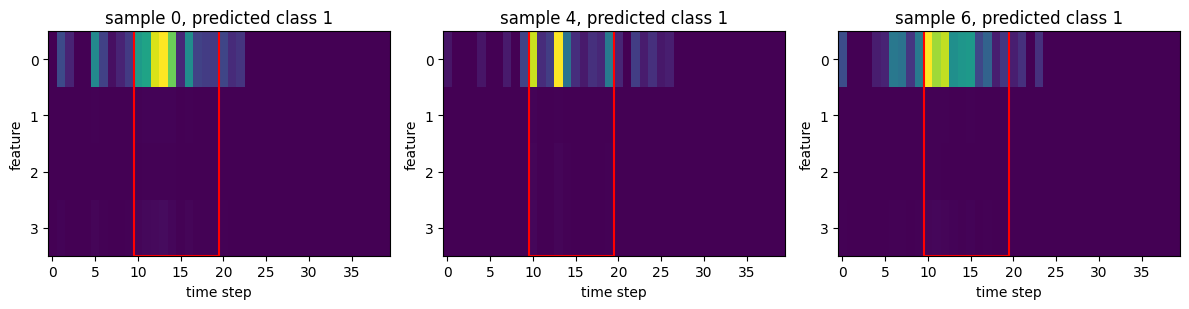

In [5]:
import matplotlib.pyplot as plt

with torch.no_grad():
    pred = model(inputs, mask_test[:16]).argmax(dim=1)

class1_idx = (pred == 1).nonzero(as_tuple=True)[0][:3]
saliency = attr[:, 1].abs().detach()  # class-1 attribution only

fig, axes = plt.subplots(1, len(class1_idx), figsize=(4 * len(class1_idx), 3.2))
for ax, i in zip(axes, class1_idx.tolist()):
    ax.imshow(saliency[i].T, aspect="auto", cmap="viridis")
    ax.axvspan(SIGNAL_START - 0.5, SIGNAL_END - 0.5, fill=False, edgecolor="red", linewidth=1.5)
    ax.set_title(f"sample {i}, predicted class 1")
    ax.set_xlabel("time step")
    ax.set_ylabel("feature")
    ax.set_yticks(range(N_FEATURES))
plt.tight_layout()
plt.show()

## Next steps

- **Multiple context tensors.** `additional_forward_args` accepts a tuple of any length,
  add sequence lengths, categorical IDs, whatever else `forward()` needs.
- **Compare classes.** Index `attr[:, c]` for any class `c`, or `attr.abs().mean(dim=1)`
  for an overall view.
- **TSlib and dict/tuple outputs.** See the [TSlib models](tslib_models.ipynb) and
  [custom outputs](custom_outputs.ipynb) notebooks.

Full recipe: [Classification models](https://khairulislam.github.io/tslens/integration/#classification-models)
in the integration cookbook.